In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
sys.path.append('../../src')
from data_loader import DataLoader
from configs.configs import SetupEnum, SamplingEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm

from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


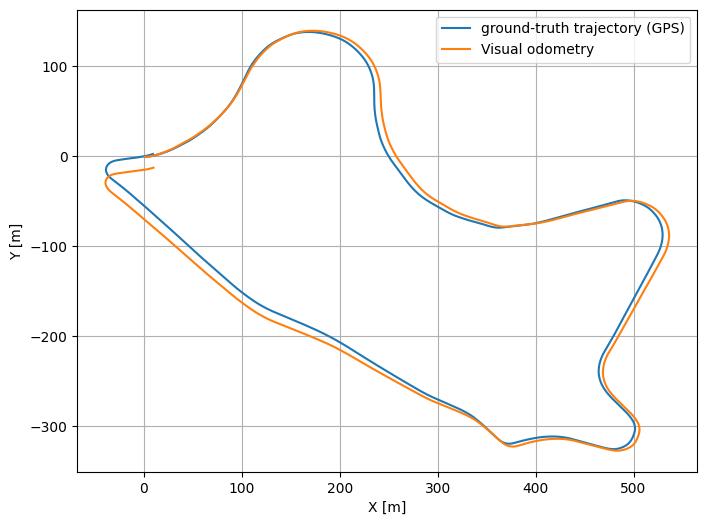

In [2]:
kitti_root_dir = '../../data'
vo_root_dir = '../../vo_estimates'
noise_vector_dir = '../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=True
                 )

In [3]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(setup=SetupEnum.SETUP_1,filter_type=FilterEnum.EKF, noise_type=NoiseTypeEnum.CURRENT)

In [4]:
acc = data.IMU_outputs[:, :3]
gyr = data.IMU_outputs[:, 3:]

In [5]:
mad = Madgwick(gyr=gyr, acc=acc)

In [6]:
mad.Q

array([[ 9.99530723e-01, -1.24644939e-02, -2.79658309e-02,
        -9.39506284e-04],
       [ 9.99532258e-01, -1.20413358e-02, -2.80818621e-02,
        -1.29646607e-03],
       [ 9.99529006e-01, -1.16532755e-02, -2.83534273e-02,
        -1.43211318e-03],
       ...,
       [ 9.57829040e-01,  1.66807661e-03,  2.08034567e-02,
        -2.86579768e-01],
       [ 9.57975994e-01,  1.88142737e-03,  2.03552251e-02,
        -2.86119068e-01],
       [ 9.57975994e-01,  1.88142737e-03,  2.03552251e-02,
        -2.86119068e-01]])

In [7]:
madgwick = Madgwick()

In [8]:
Q = np.tile(x[6:].reshape(-1), (data.N, 1)) # Allocate for quaternions

In [9]:
def compute_norm_w(w):
    return np.sqrt(np.sum(w**2))
    
def get_rotation_matrix(q):
    q0, q1, q2, q3 = q[:, 0]
    # https://ahrs.readthedocs.io/en/latest/filters/ekf.html
    # https://www.iri.upc.edu/people/jsola/JoanSola/objectes/notes/kinematics.pdf
    return np.array([
        [q0**2 + q1**2 - q2**2 - q3**2, 2*(q1*q2 - q0*q3), 2*(q1*q3 + q0*q2)],
        [2*(q1*q2 + q0*q3), q0**2 - q1**2 + q2**2 - q3**2, 2*(q2*q3 - q0*q1)],
        [2*(q1*q3 - q0*q2), 2*(q2*q3 + q0*q1), q0**2 - q1**2 - q2**2 + q3**2]
    ])
    # return np.array([ 
    #     [1 - 2*q2**2 - 2*q3**2, 2*(q1*q2 + q0*q3), 2*(q1*q3 - q0*q2)],
    #     [2*(q1*q2 - q0*q3), 1 - 2*q1**2 - 2*q3**2, 2*(q2*q3 + q0*q1)],
    #     [2*(q1*q3 + q0*q2), 2*(q2*q3 - q1*q0), 1 - 2*q1**2 - 2*q2**2]
    # ])
    # return np.array([
    #     [q0**2 + q1**2 - q2**2 - q3**2, 2*(q1*q2 + q0*q3), 2*(q1*q3 - q0*q2)],
    #     [2*(q1*q2 - q0*q3), q0**2 - q1**2 + q2**2 - q3**2, 2*(q2*q3 + q0*q1)],
    #     [2*(q1*q3 + q0*q2), 2*(q2*q3 - q0*q1), q0**2 - q1**2 - q2**2 + q3**2]
    # ])



def get_quaternion_update_matrix(w, flip=False):
    wx, wy, wz = w[:, 0]
    # https://ahrs.readthedocs.io/en/latest/filters/ekf.html
    # https://www.iri.upc.edu/people/jsola/JoanSola/objectes/notes/kinematics.pdf
    # return np.array([ # w, x, y, z
    #     [0, -wx, -wy, -wz],
    #     [wx, 0, wz, -wy],
    #     [wy, -wz, 0, wx],
    #     [wz, wy, -wx, 0]
    # ])
    # return np.array([
    #     [0, wz, -wy, wx],
    #     [-wz, 0, wx, wy],
    #     [wy, -wx, 0, wz],
    #     [-wx, -wy, -wz, 0]
    # ])
    if flip:
        return np.array([ # w, x, y, z
            [0, -wx, -wy, -wz],
            [wx, 0, wz, -wy],
            [wy, -wz, 0, wx],
            [wz, wy, -wx, 0]
        ])
    return np.array([ # w, x, y, z
        [0, -wx, -wy, -wz],
        [wx, 0, -wz, wy],
        [wy, wz, 0, -wx],
        [wz, -wy, wx, 0]
    ])
        


def get_quaternion(u, q_prev):
    return madgwick.updateIMU(q_prev.flatten(), gyr=u[3:], acc=u[:3])

def get_euler_angle_from_quaternion(q):
    w, x, y, z = q
    roll = np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2))
    pitch = -np.pi/2 + 2*np.arctan2(np.sqrt(1 + 2*(w*y - x*z)), np.sqrt(1-2*(w*y - x*z)))
    yaw = np.arctan2(2*(w*z + x*y), 1-2*(y**2 + z**2))
    
    return np.array([roll, pitch, yaw])

In [11]:
x, _, _, _, _, _ = data.get_initial_data(setup=SetupEnum.SETUP_1,filter_type=FilterEnum.EKF, noise_type=NoiseTypeEnum.CURRENT)
Q1 = np.tile(x[6:].reshape(-1), (data.N, 1)) # Allocate for quaternions
Q2 = np.tile(x[6:].reshape(-1), (data.N, 1)) # Allocate for quaternions

initial_v = np.zeros((3, 1))
v1 = [initial_v]
v2 = [initial_v]

g = np.array([[0],[0],[9.81]])

t_last = 0.

for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    # with noise
    # ax, ay, az = data.IMU_acc_with_noise[t_idx]
    # wx, wy, wz = data.IMU_angular_velocity_with_noise[t_idx]

    # without noise
    ax, ay, az = data.IMU_outputs[t_idx, :3]
    wx, wy, wz = data.IMU_outputs[t_idx, 3:]
    
    u = np.array([
        ax,
        ay,
        az,
        wx,
        wy,
        wz
    ])
    a = u[:3]
    a = a.reshape(-1, 1)
    w = u[3:]
    w = w.reshape(-1, 1)
    
    Q1[t_idx] = get_quaternion(u, q_prev=Q1[t_idx -1])

    # flip = False
    # if t_idx > 1050:
    #     flip = True
    Omega = get_quaternion_update_matrix(w)
    norm_w = compute_norm_w(w)
    A = np.cos(norm_w*dt/2) * np.eye(4)
    B = (1/norm_w)*np.sin(norm_w*dt/2) * Omega

    q_k = np.array(A + B) @ Q2[t_idx-1]
    q_k /= np.linalg.norm(q_k)
    Q2[t_idx] = q_k

    R1 = get_rotation_matrix(Q1[t_idx - 1].reshape(-1, 1))
    R2 = get_rotation_matrix(Q2[t_idx - 1].reshape(-1, 1))
    
    v_1 = v1[t_idx-1] + (R1 @ a - g) * dt
    v_2 = v2[t_idx-1] + (R2 @ a - g) * dt

    v1.append(v_1)
    v2.append(v_2)
    
    t_last = t

w1 = np.array([get_euler_angle_from_quaternion(q) for q in Q1])
w2 = np.array([get_euler_angle_from_quaternion(q) for q in Q2])

v1 = np.array([v.reshape(-1) for v in v1])
v2 = np.array([v.reshape(-1) for v in v2])

100%|███████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 17240.43it/s]


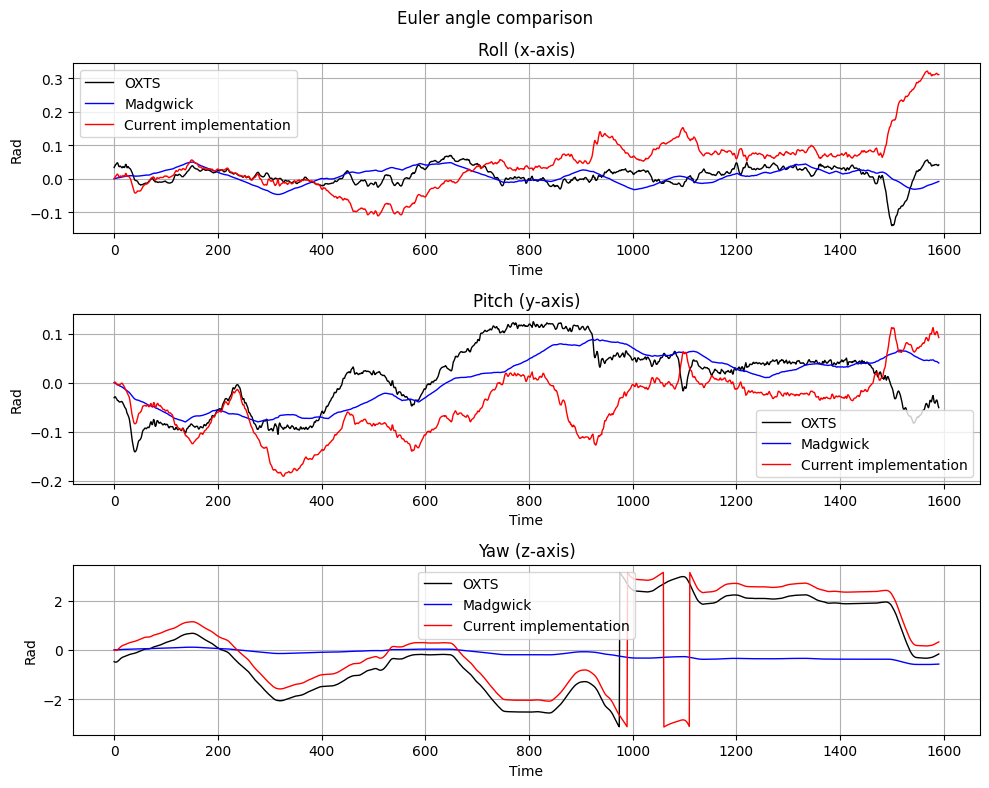

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Euler angle comparison')

t = [i for i in range(0, w1.shape[0])]

labels = ["Roll (x-axis)", "Pitch (y-axis)", "Yaw (z-axis)"]
for i in range(0, 3):
    angle = data.INS_angles[:, i]
    axs[i].plot(t, angle, lw=1, label='OXTS', color='black')
    angle = w1[:, i]
    axs[i].plot(t, angle, lw=1, label='Madgwick', color='blue')
    angle = w2[:, i]
    axs[i].plot(t, angle, lw=1, label='Current implementation', color='red')

    # axs[i].set_ylim([-5, 5])
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Rad')
    axs[i].title.set_text(labels[i])
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()

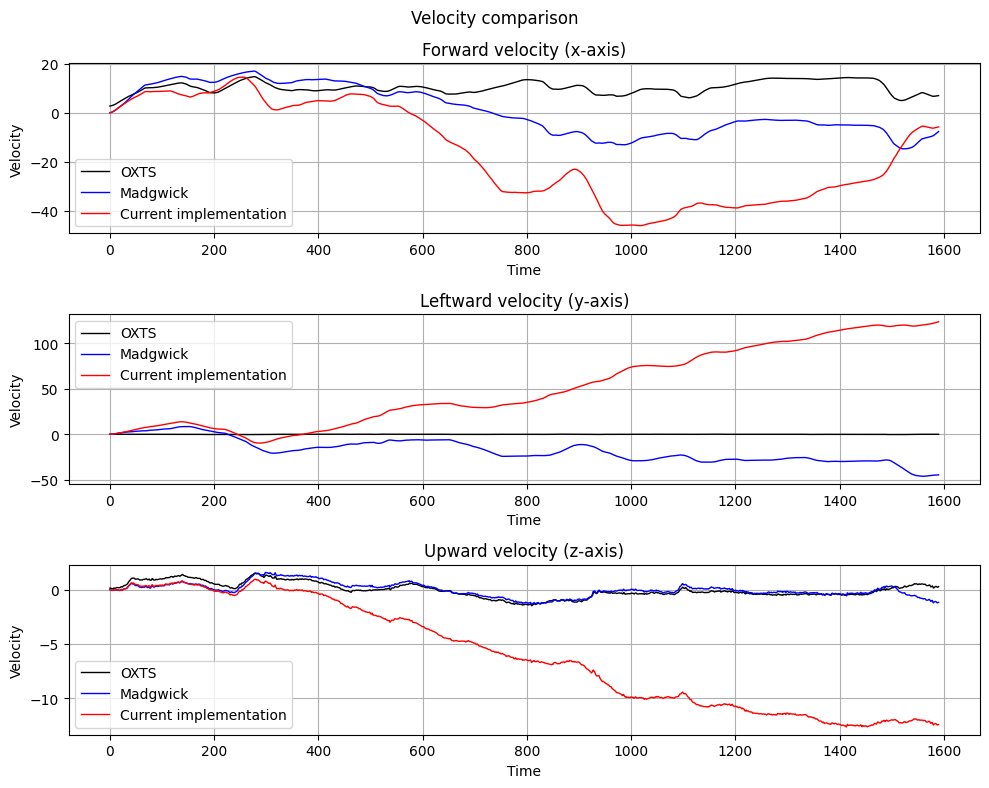

In [197]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Velocity comparison')

t = [i for i in range(0, w1.shape[0])]

labels = ["Forward velocity (x-axis)", "Leftward velocity (y-axis)", "Upward velocity (z-axis)"]
for i in range(0, 3):
    vel = data.INS_velocities[:, i]
    axs[i].plot(t, vel, lw=1, label='OXTS', color='black')
    vel = v1[:, i]
    axs[i].plot(t, vel, lw=1, label='Madgwick', color='blue')
    vel = v2[:, i]
    axs[i].plot(t, vel, lw=1, label='Current implementation', color='red')
    
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Velocity')
    axs[i].title.set_text(labels[i])
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()